# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Mortgage Loan Dataset](https://www.kaggle.com/datasets/chukwuemeka64/mortgage-data/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('mortgage_loan_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD)
0,Male,36,Yes,PhD,Software Engineer,13,134183.86,0.08,101706.78,682,2045.80,Urban,3,498842.67
1,Female,63,No,High School,Freelancer,37,68884.95,0.03,46324.29,823,804.73,Suburban,10,536232.53
2,Female,33,Yes,PhD,Nurse,11,76396.27,0.03,13045.79,813,1050.54,Urban,0,518884.47
3,Female,51,Yes,Bachelor's,Business Owner,29,115968.80,0.05,60388.40,752,904.08,Rural,2,757940.14
4,Male,53,Yes,Bachelor's,Nurse,27,99977.38,0.06,54838.14,728,2285.76,Rural,1,283110.21


## last Five row

In [4]:
df.tail()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD)
49985,Female,57,Yes,Master's,Doctor,38,155977.43,0.03,85565.49,850,2661.55,Rural,5,995780.28
49986,Male,56,Yes,Bachelor's,Banker,29,109407.93,0.05,33965.15,781,1029.63,Suburban,3,659523.17
49987,Female,55,No,Bachelor's,Banker,33,110671.03,0.09,62713.63,666,1511.39,Suburban,1,354407.87
49988,Female,67,Yes,Bachelor's,Doctor,42,125888.77,0.04,28860.76,810,1954.98,Suburban,5,713931.03
49989,Female,30,Yes,Master's,Software Engineer,2,109885.05,0.03,56409.64,800,1742.82,Rural,3,688714.37


## Shape of our dataset

In [5]:
df.shape

(49990, 14)

## List out all columns

In [6]:
df.columns

Index(['Gender', 'Age', 'Married', 'Education', 'Job', 'Employment Years',
       'Annual Income (USD)', 'Interest Rate', 'Down Payment (USD)',
       'Credit Score', 'Existing Monthly Debt (USD)', 'Area', 'Loans Repaid',
       'Max Loan Amount (USD)'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Gender                          object
Age                              int64
Married                         object
Education                       object
Job                             object
Employment Years                 int64
Annual Income (USD)            float64
Interest Rate                  float64
Down Payment (USD)             float64
Credit Score                     int64
Existing Monthly Debt (USD)    float64
Area                            object
Loans Repaid                     int64
Max Loan Amount (USD)          float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49990 entries, 0 to 49989
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       49990 non-null  object 
 1   Age                          49990 non-null  int64  
 2   Married                      49990 non-null  object 
 3   Education                    49990 non-null  object 
 4   Job                          49990 non-null  object 
 5   Employment Years             49990 non-null  int64  
 6   Annual Income (USD)          49990 non-null  float64
 7   Interest Rate                49990 non-null  float64
 8   Down Payment (USD)           49990 non-null  float64
 9   Credit Score                 49990 non-null  int64  
 10  Existing Monthly Debt (USD)  49990 non-null  float64
 11  Area                         49990 non-null  object 
 12  Loans Repaid                 49990 non-null  int64  
 13  Max Loan Amount 

## Check Null Value

In [9]:
df.isnull().sum()

Gender                         0
Age                            0
Married                        0
Education                      0
Job                            0
Employment Years               0
Annual Income (USD)            0
Interest Rate                  0
Down Payment (USD)             0
Credit Score                   0
Existing Monthly Debt (USD)    0
Area                           0
Loans Repaid                   0
Max Loan Amount (USD)          0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Age,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Loans Repaid,Max Loan Amount (USD)
count,49990.000000,49990.000000,49990.000000,49990.000000,49990.000000,49990.000000,49990.000000,49990.000000,4.999000e+04
mean,57.046609,32.068234,120323.418437,0.050957,64296.936887,760.373195,1656.598654,5.825545,6.634191e+05
std,16.947352,15.171406,36965.115132,0.020815,39594.864102,63.385441,751.032649,3.431778,3.126811e+05
min,28.000000,0.000000,25000.000000,0.030000,5000.000000,580.000000,0.000000,0.000000,2.614254e+04
25%,42.000000,19.000000,95011.170000,0.030000,34152.762500,717.000000,1099.917500,3.000000,4.254228e+05
50%,57.000000,34.000000,119978.225000,0.050000,59097.870000,764.000000,1564.655000,5.000000,6.232435e+05
75%,72.000000,48.000000,145455.785000,0.060000,87905.060000,811.000000,2140.255000,8.000000,8.641049e+05
max,86.000000,50.000000,274740.320000,0.120000,250000.000000,850.000000,5000.000000,24.000000,2.270836e+06


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

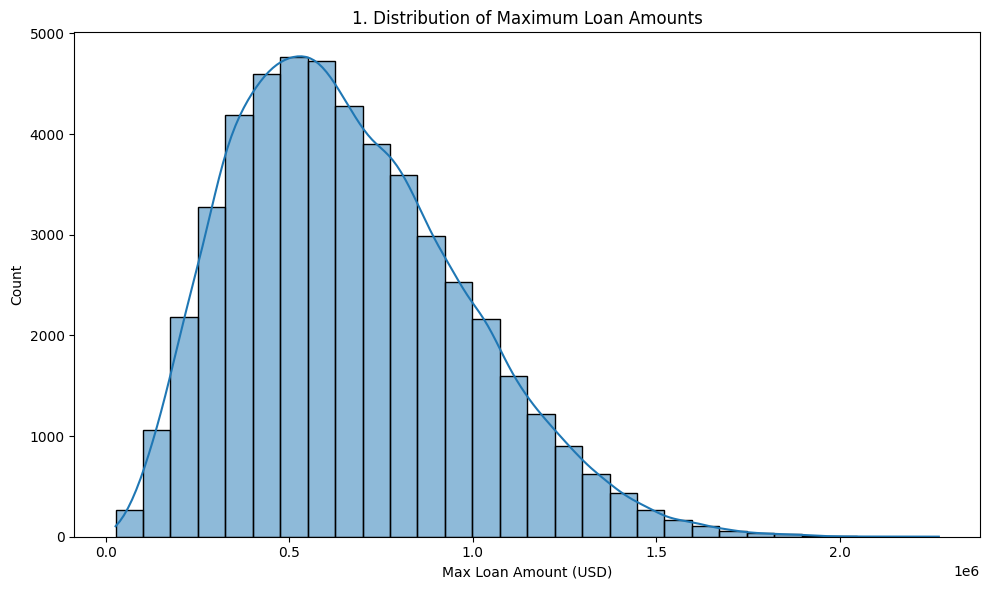

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Max Loan Amount (USD)', bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Maximum Loan Amounts')
show_fig()
plot_no += 1

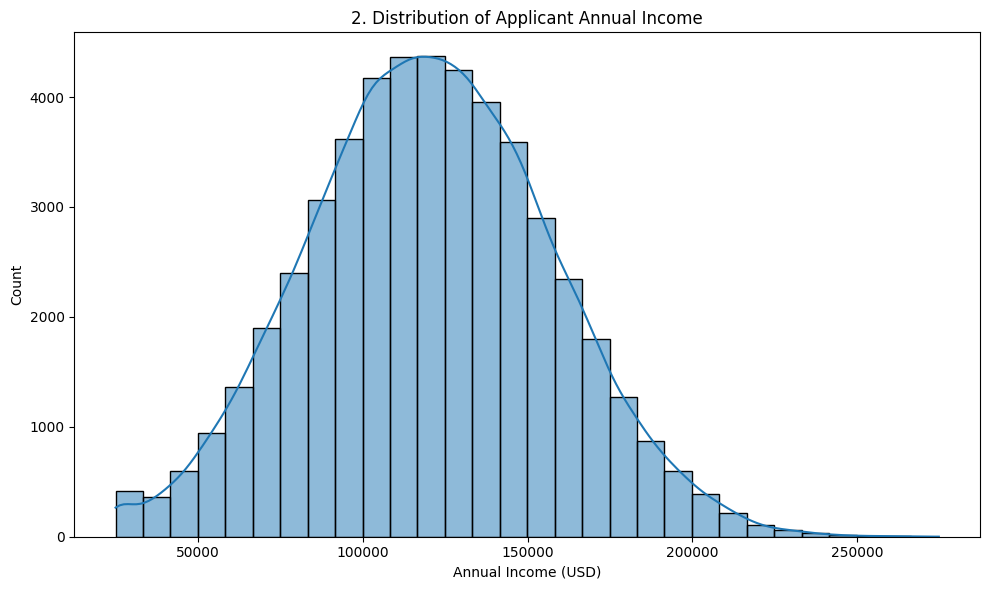

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Annual Income (USD)', bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Applicant Annual Income')
show_fig()
plot_no += 1

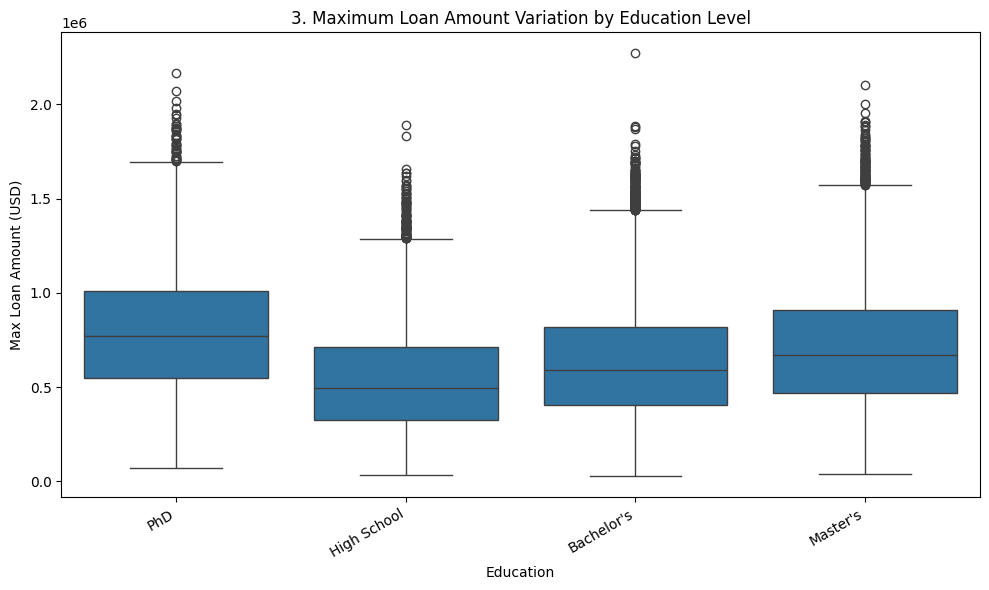

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Education', y='Max Loan Amount (USD)')
plt.xticks(rotation=30, ha='right')
plt.title(f'{plot_no}. Maximum Loan Amount Variation by Education Level')
show_fig()
plot_no += 1

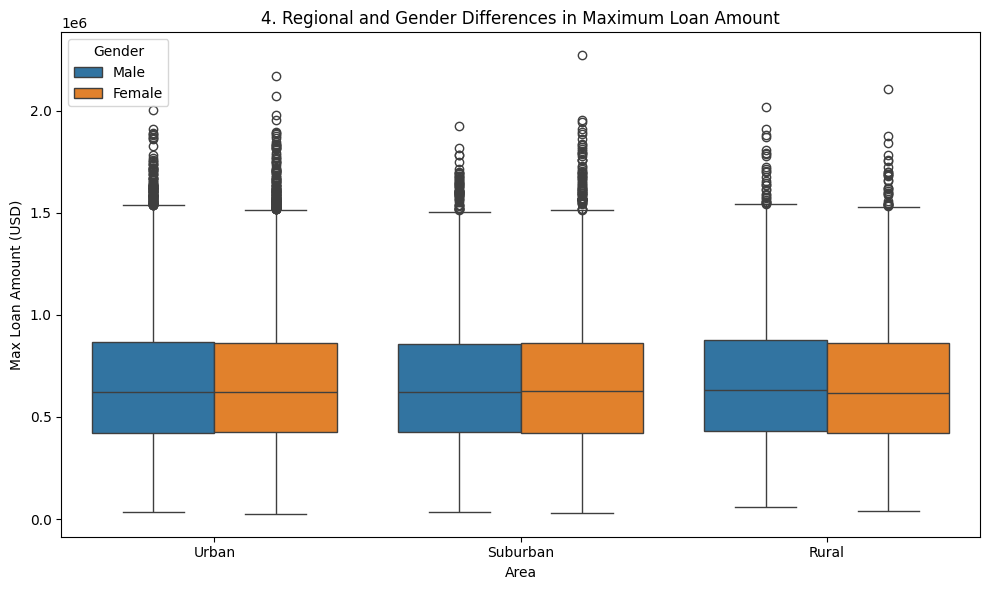

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Area', y='Max Loan Amount (USD)', hue='Gender')
plt.title(f'{plot_no}. Regional and Gender Differences in Maximum Loan Amount')
show_fig()
plot_no += 1

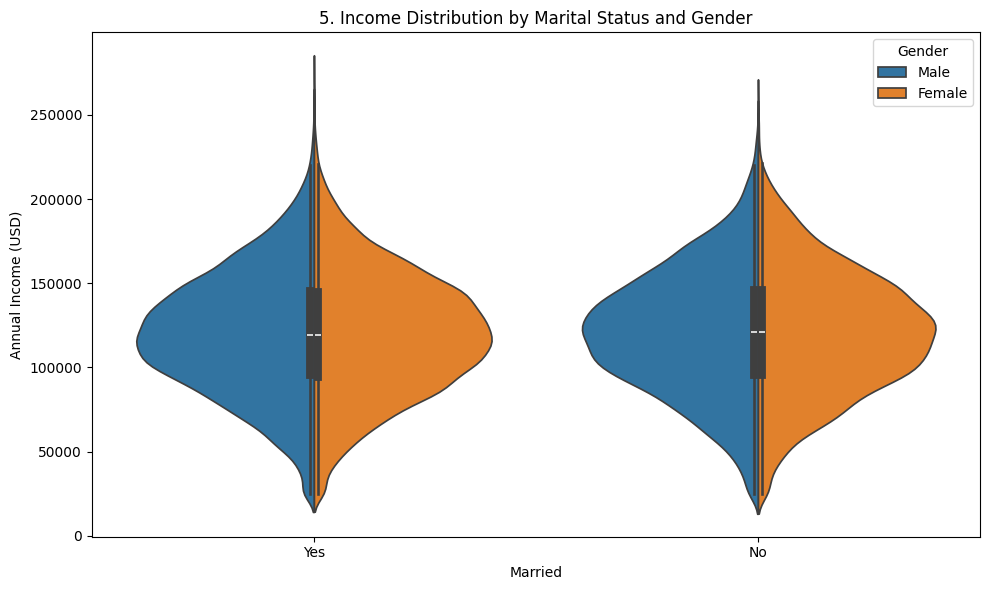

In [17]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Married', y='Annual Income (USD)', hue='Gender', split=True)
plt.title(f'{plot_no}. Income Distribution by Marital Status and Gender')
show_fig()
plot_no += 1

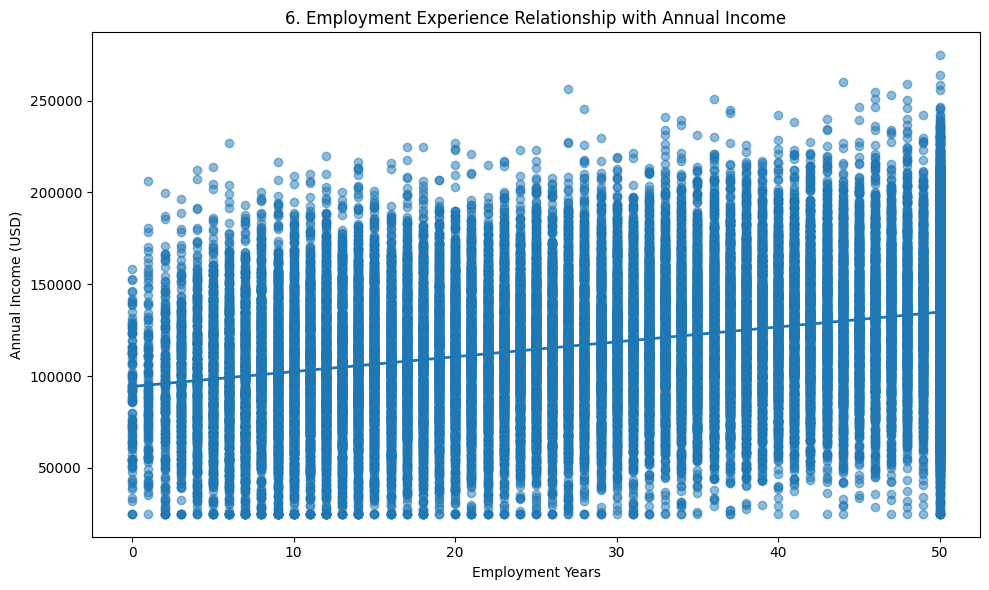

In [18]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Employment Years', y='Annual Income (USD)', scatter_kws={'alpha': 0.5}, line_kws={'linewidth': 2})
plt.title(f'{plot_no}. Employment Experience Relationship with Annual Income')
show_fig()
plot_no += 1

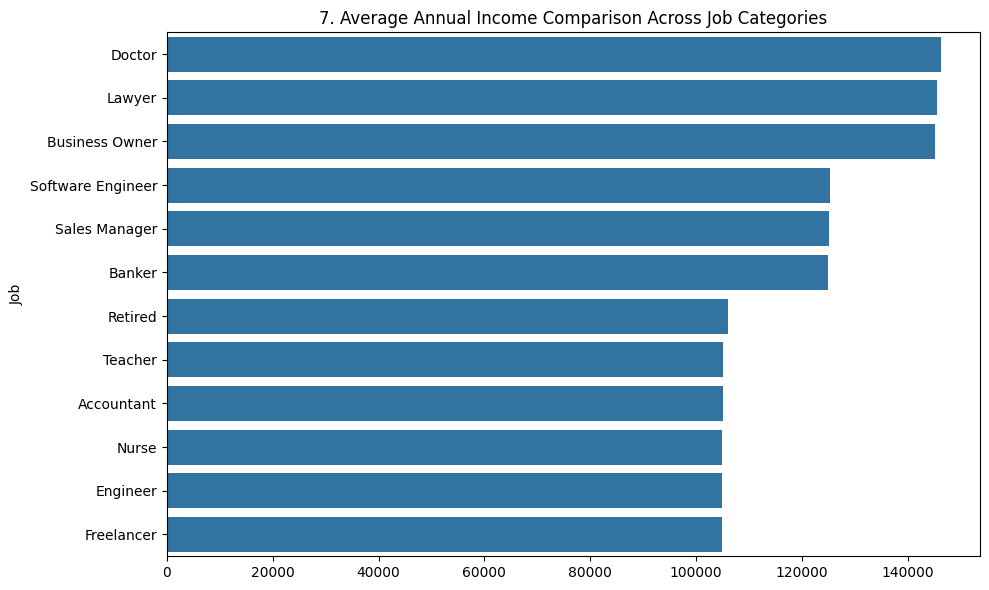

In [19]:
fig = plt.figure(figsize=(10,6))
job_income = df.groupby('Job')['Annual Income (USD)'].mean().sort_values(ascending=False)
sns.barplot(x=job_income.values, y=job_income.index)
plt.title(f'{plot_no}. Average Annual Income Comparison Across Job Categories')
show_fig()
plot_no += 1

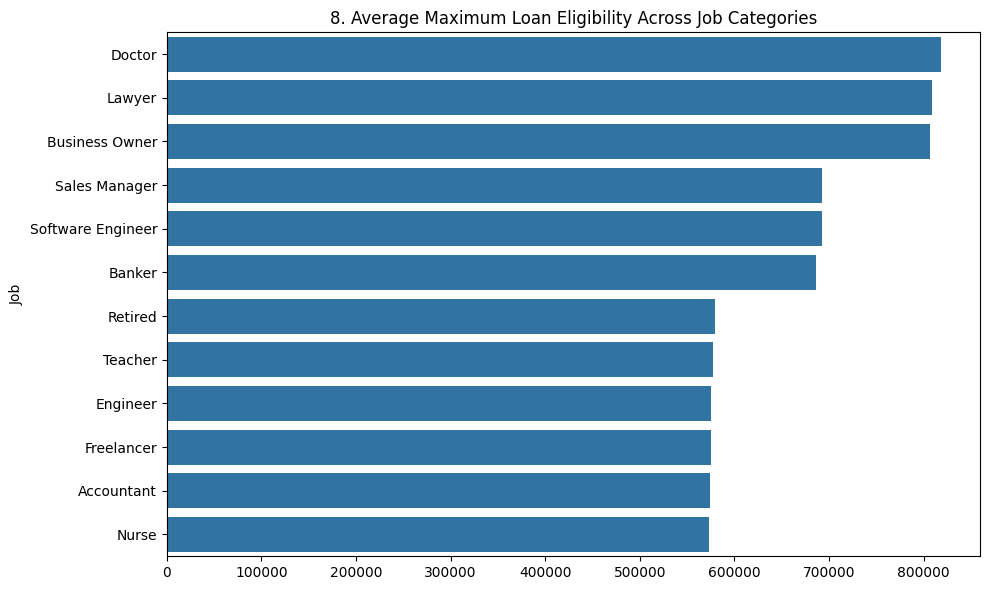

In [20]:
fig = plt.figure(figsize=(10,6))
job_loan = df.groupby('Job')['Max Loan Amount (USD)'].mean().sort_values(ascending=False)
sns.barplot(x=job_loan.values, y=job_loan.index)
plt.title(f'{plot_no}. Average Maximum Loan Eligibility Across Job Categories')
show_fig()
plot_no += 1

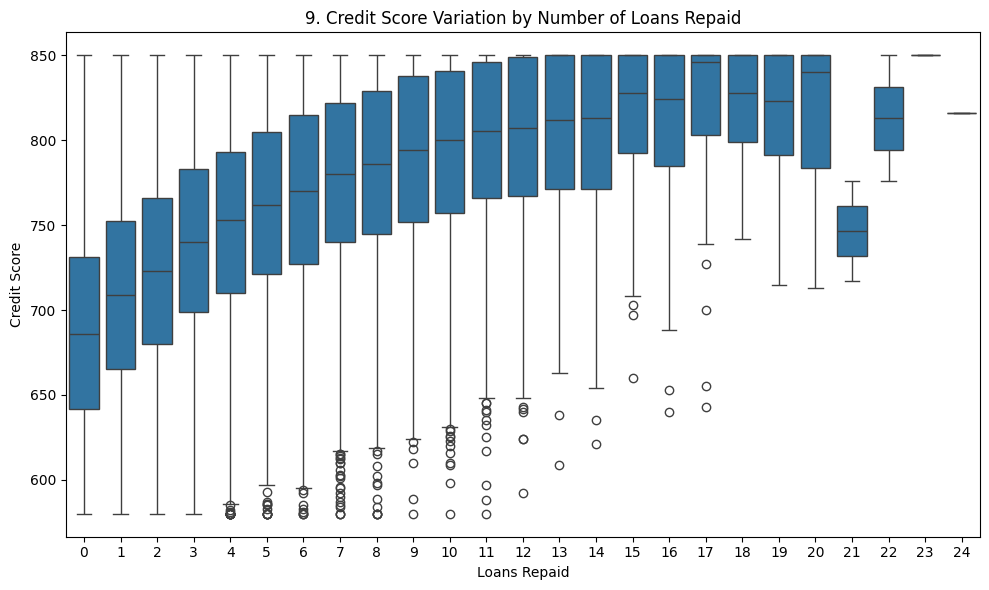

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Loans Repaid', y='Credit Score')
plt.title(f'{plot_no}. Credit Score Variation by Number of Loans Repaid')
show_fig()
plot_no += 1

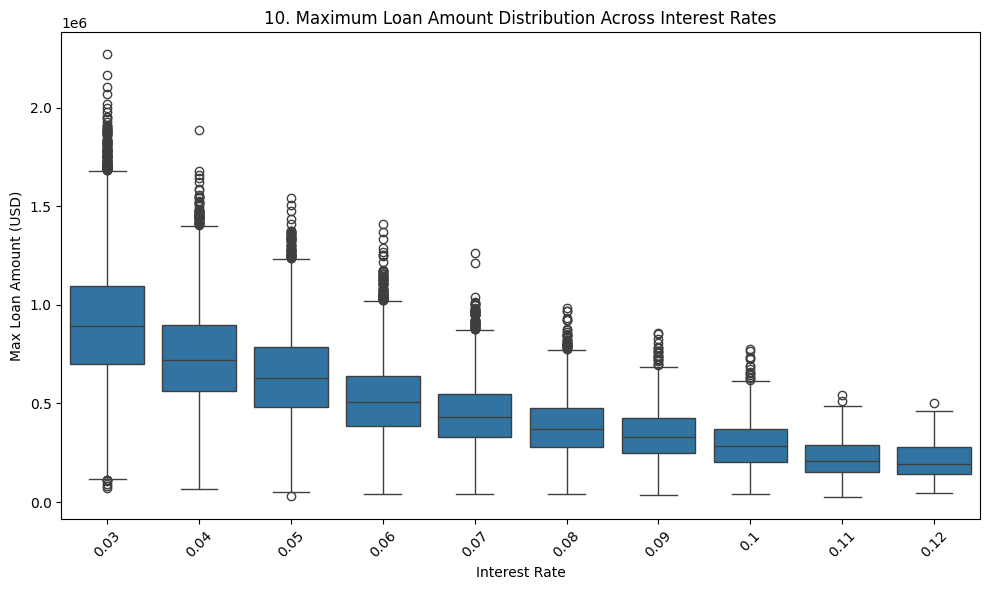

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Interest Rate', y='Max Loan Amount (USD)')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Maximum Loan Amount Distribution Across Interest Rates')
show_fig()
plot_no += 1

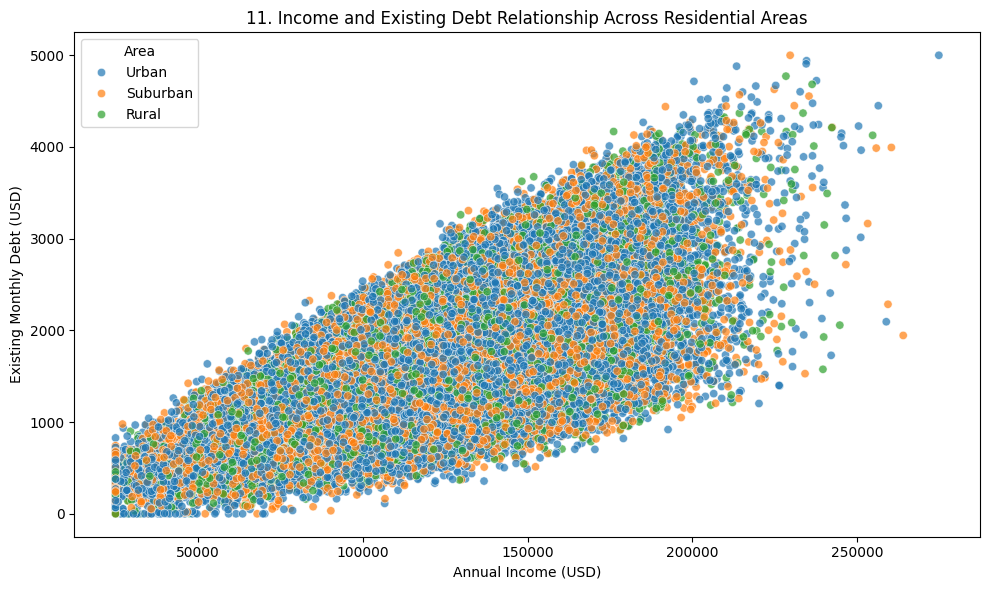

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Annual Income (USD)', y='Existing Monthly Debt (USD)', hue='Area', alpha=0.7)
plt.title(f'{plot_no}. Income and Existing Debt Relationship Across Residential Areas')
show_fig()
plot_no += 1

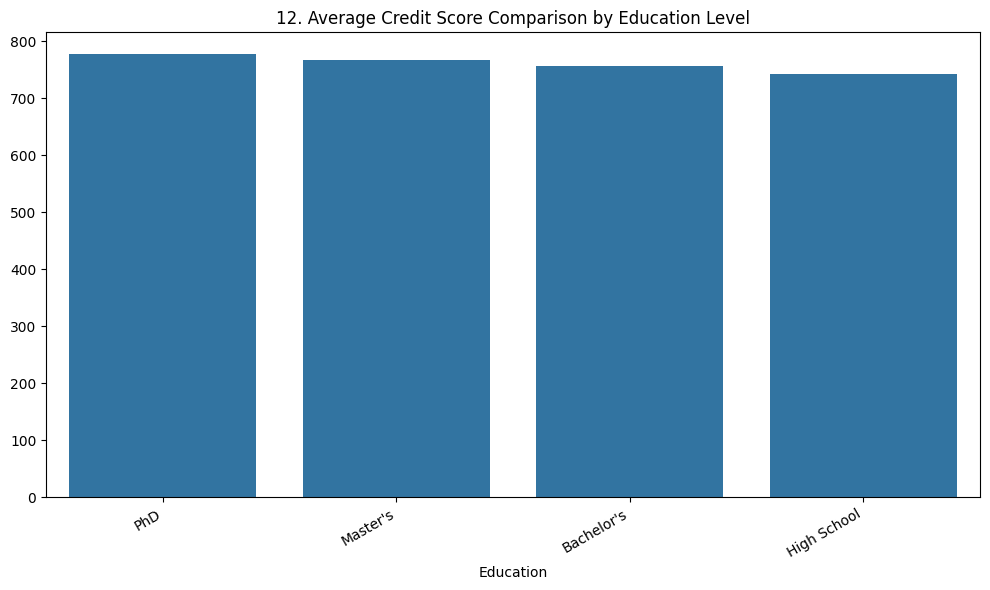

In [24]:
fig = plt.figure(figsize=(10,6))
education_credit = df.groupby('Education')['Credit Score'].mean().sort_values(ascending=False)
sns.barplot(x=education_credit.index, y=education_credit.values)
plt.xticks(rotation=30, ha='right')
plt.title(f'{plot_no}. Average Credit Score Comparison by Education Level')
show_fig()
plot_no += 1

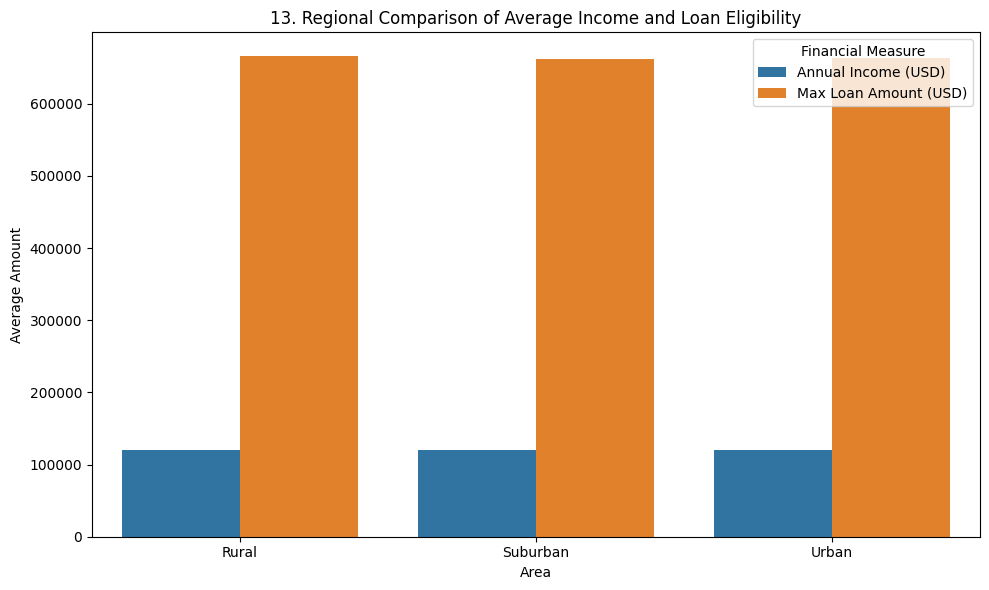

In [25]:
fig = plt.figure(figsize=(10,6))
area_summary = df.groupby('Area')[['Annual Income (USD)', 'Max Loan Amount (USD)']].mean().reset_index()
area_summary_melted = area_summary.melt(id_vars='Area', var_name='Financial Measure', value_name='Average Amount')
sns.barplot(data=area_summary_melted, x='Area', y='Average Amount', hue='Financial Measure')
plt.title(f'{plot_no}. Regional Comparison of Average Income and Loan Eligibility')
show_fig()
plot_no += 1

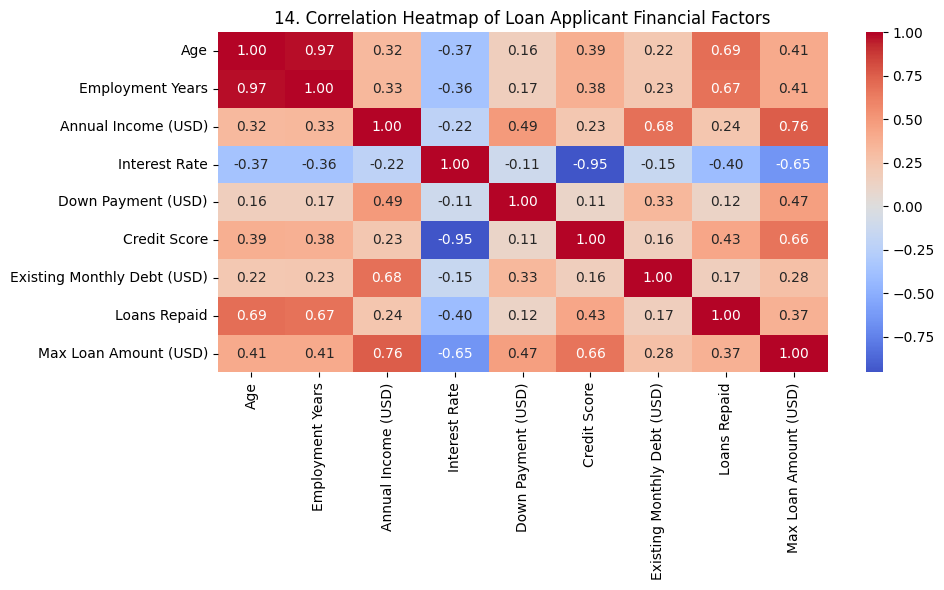

In [26]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title(f'{plot_no}. Correlation Heatmap of Loan Applicant Financial Factors')
show_fig()
plot_no += 1

# Model Training

## Separate input features and target

In [27]:
X = df.drop(columns=['Max Loan Amount (USD)'])
y = df['Max Loan Amount (USD)']

## Identify numerical and categorical columns

In [28]:
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = X.select_dtypes(include=['object', 'category']).columns

## Create numerical preprocessing pipeline

In [29]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## Create categorical preprocessing pipeline

In [30]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

## Combine numerical and categorical preprocessing

In [31]:
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_columns),
    ('categorical', categorical_pipeline, categorical_columns)
])

## Create Gradient Boosting regression model

In [32]:
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    loss='huber',
    random_state=42
)

## Create complete machine learning pipeline

In [33]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

## Split dataset into training and testing sets

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Train the model

In [35]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict maximum loan amounts

In [36]:
y_pred = pipeline.predict(X_test)

## Calculate regression performance scores

In [37]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

## Print model performance

In [38]:
print(f'Model Accuracy (R² Score): {r2 * 100:.2f}%')
print(f'Mean Absolute Error: ${mae:,.2f}')
print(f'Root Mean Squared Error: ${rmse:,.2f}')

Model Accuracy (R² Score): 99.31%
Mean Absolute Error: $18,728.89
Root Mean Squared Error: $25,845.90


## Plot actual versus predicted values

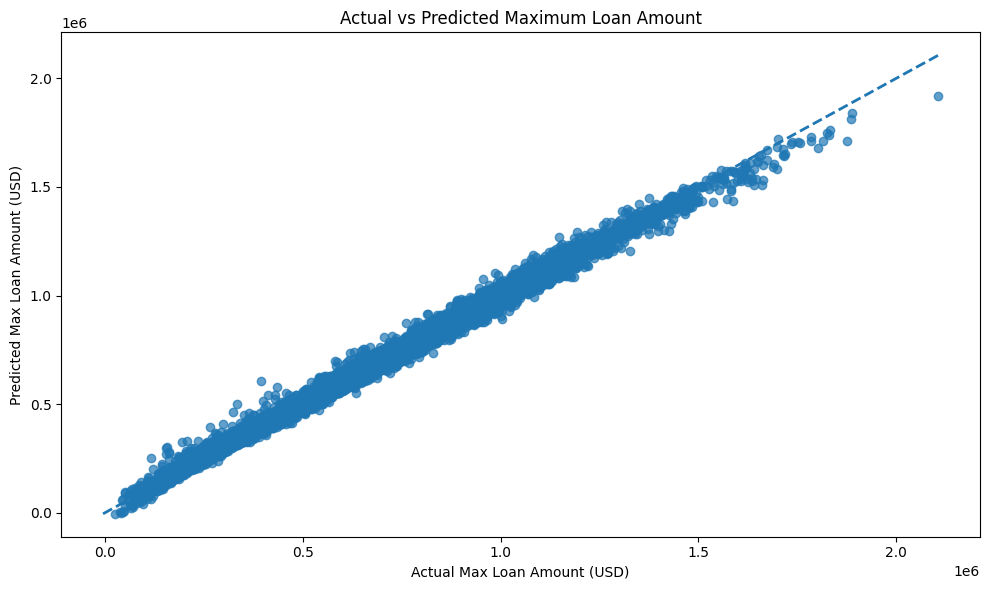

In [39]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
minimum_value = min(y_test.min(), y_pred.min())
maximum_value = max(y_test.max(), y_pred.max())
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle='--',
    linewidth=2
)
plt.xlabel('Actual Max Loan Amount (USD)')
plt.ylabel('Predicted Max Loan Amount (USD)')
plt.title('Actual vs Predicted Maximum Loan Amount')
plt.tight_layout()
plt.show()